# Crop Yield Prediction 

The objective of this project is to use machine learning techniques to successfully forecast the annual yield of some of the world's 10 most consumed crops.

1. Cassava
2. Maize
3. Plantains
4. Potatos
5. Rice
6. Sorgum
7. Soybeans
8. Sweet Potatos
9. Wheat
10. Yams

Public Data Sources: 
- FAOSTAT (Food and Agriculture Organization of the United Nations) 
- World Bank

# Part 1 - Data Importation and Cleaning

## Dataset 1 - Crop Yield Data

In [1]:
import numpy as np
import pandas as pd

In [2]:
faostat_data = pd.read_csv('faostat_data.csv', encoding='latin-1')
faostat_data.shape

(56717, 12)

In [3]:
faostat_data.head()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
0,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1961,1961,hg/ha,14000
1,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1962,1962,hg/ha,14000
2,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1963,1963,hg/ha,14260
3,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1964,1964,hg/ha,14257
4,QC,Crops,2,Afghanistan,5419,Yield,56,Maize,1965,1965,hg/ha,14400


In [4]:
faostat_data.tail()

,Domain Code,Domain,Area Code,Area,Element Code,Element,Item Code,Item,Year Code,Year,Unit,Value
56712,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2012,2012,hg/ha,24420
56713,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2013,2013,hg/ha,22888
56714,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2014,2014,hg/ha,21357
56715,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2015,2015,hg/ha,19826
56716,QC,Crops,181,Zimbabwe,5419,Yield,15,Wheat,2016,2016,hg/ha,18294


In [5]:
faostat_data.columns

Index(['Domain Code', 'Domain', 'Area Code', 'Area', 'Element Code', 'Element',
       'Item Code', 'Item', 'Year Code', 'Year', 'Unit', 'Value'],
      dtype='object')

In [6]:
# Drop unwanted columns

faostat_data = faostat_data.drop(['Domain Code', 'Domain', 'Area Code', 'Element Code', 'Element', 'Item Code', 'Year Code', 'Unit'], axis=1)

faostat_data.head()

,Area,Item,Year,Value
0,Afghanistan,Maize,1961,14000
1,Afghanistan,Maize,1962,14000
2,Afghanistan,Maize,1963,14260
3,Afghanistan,Maize,1964,14257
4,Afghanistan,Maize,1965,14400


In [7]:
faostat_data.describe()

,Year,Value
count,56717.000000,56717.000000
mean,1989.669570,62094.660084
std,16.133198,67835.932856
min,1961.000000,0.000000
25%,1976.000000,15680.000000
50%,1991.000000,36744.000000
75%,2004.000000,86213.000000
max,2016.000000,1000000.000000


The cell above informs the FAOSTAT dataframe stores crop yield data from 1961 to 2016.

In [8]:
faostat_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56717 entries, 0 to 56716
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Area    56717 non-null  object
 1   Item    56717 non-null  object
 2   Year    56717 non-null  int64 
 3   Value   56717 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1.7+ MB


Moreover, we can confirm there are no apparent missing values and all columns have the expected data type for each category.

## Dataset 2 - Rainfall Data

In [9]:
wbo_data = pd.read_csv('wbo_data.csv', encoding='latin-1')

In [10]:
wbo_data.head()

,Area,Year,average_rain_fall_mm_per_year
0,Afghanistan,1985.0,327
1,Afghanistan,1986.0,327
2,Afghanistan,1987.0,327
3,Afghanistan,1989.0,327
4,Afghanistan,1990.0,327


In [11]:
wbo_data.tail()

,Area,Year,average_rain_fall_mm_per_year
56712,NaN,NaN,NaN
56713,NaN,NaN,NaN
56714,NaN,NaN,NaN
56715,NaN,NaN,NaN
56716,NaN,NaN,NaN


NaN values need to be addressed

In [12]:
wbo_data = wbo_data.dropna()

In [13]:
wbo_data.tail()

,Area,Year,average_rain_fall_mm_per_year
6722,Zimbabwe,2013.0,657
6723,Zimbabwe,2014.0,657
6724,Zimbabwe,2015.0,657
6725,Zimbabwe,2016.0,657
6726,Zimbabwe,2017.0,657


In [14]:
wbo_data.columns

Index([' Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [15]:
wbo_data = wbo_data.rename(index=str, columns={' Area':'Area'})

In [16]:
wbo_data.columns

Index(['Area', 'Year', 'average_rain_fall_mm_per_year'], dtype='object')

In [17]:
wbo_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5953 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           5953 non-null   object 
 1   Year                           5953 non-null   float64
 2   average_rain_fall_mm_per_year  5953 non-null   object 
dtypes: float64(1), object(2)
memory usage: 186.0+ KB


One variable, "average_rain_fall_mm_per_year" should be numeric instead of integer.

In [18]:
wbo_data = wbo_data.drop(wbo_data[wbo_data['average_rain_fall_mm_per_year'] == '..'].index)

wbo_data['average_rain_fall_mm_per_year'] = pd.to_numeric(wbo_data['average_rain_fall_mm_per_year']).astype(float)

In [19]:
wbo_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5947 entries, 0 to 6726
Data columns (total 3 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           5947 non-null   object 
 1   Year                           5947 non-null   float64
 2   average_rain_fall_mm_per_year  5947 non-null   float64
dtypes: float64(2), object(1)
memory usage: 185.8+ KB


In [20]:
wbo_data.describe()

,Year,average_rain_fall_mm_per_year
count,5947.000000,5947.000000
mean,2001.365899,1124.743232
std,9.526335,786.257365
min,1985.000000,51.000000
25%,1993.000000,534.000000
50%,2001.000000,1010.000000
75%,2010.000000,1651.000000
max,2017.000000,3240.000000


In [21]:
yield_data = pd.merge(faostat_data, wbo_data, on=['Year', 'Area'])

In [22]:
yield_data.head()

,Area,Item,Year,Value,average_rain_fall_mm_per_year
0,Afghanistan,Maize,1985,16652,327.0
1,Afghanistan,Potatoes,1985,140909,327.0
2,Afghanistan,"Rice, paddy",1985,22482,327.0
3,Afghanistan,Wheat,1985,12277,327.0
4,Afghanistan,Maize,1986,16875,327.0


In [23]:
yield_data.describe()

,Year,Value,average_rain_fall_mm_per_year
count,25385.000000,25385.000000,25385.000000
mean,2001.278787,68312.278353,1254.849754
std,9.143915,75213.292733,804.449430
min,1985.000000,50.000000,51.000000
25%,1994.000000,17432.000000,630.000000
50%,2001.000000,38750.000000,1150.000000
75%,2009.000000,94286.000000,1761.000000
max,2016.000000,554855.000000,3240.000000


The merged dataframe now starts at 1985 since that's the first year of the WBO rainfall dataset

## Dataset 3 - Pesticide Data

In [24]:
pesticide_data = pd.read_csv('pesticide_data.csv', encoding='latin-1')

In [25]:
pesticide_data.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Pesticides Use,Albania,Use,Pesticides (total),1990,tonnes of active ingredients,121.0
1,Pesticides Use,Albania,Use,Pesticides (total),1991,tonnes of active ingredients,121.0
2,Pesticides Use,Albania,Use,Pesticides (total),1992,tonnes of active ingredients,121.0
3,Pesticides Use,Albania,Use,Pesticides (total),1993,tonnes of active ingredients,121.0
4,Pesticides Use,Albania,Use,Pesticides (total),1994,tonnes of active ingredients,201.0


In [26]:
pesticide_data = pesticide_data.rename(index=str, columns={"Value":"pesticide_tonnes"})

pesticide_data = pesticide_data.drop(['Domain', 'Element', 'Item', 'Unit'], axis=1)

pesticide_data.head()

,Area,Year,pesticide_tonnes
0,Albania,1990,121.0
1,Albania,1991,121.0
2,Albania,1992,121.0
3,Albania,1993,121.0
4,Albania,1994,201.0


In [27]:
pesticide_data.describe()

,Year,pesticide_tonnes
count,4349.000000,4.349000e+03
mean,2003.138883,2.030334e+04
std,7.728044,1.177362e+05
min,1990.000000,0.000000e+00
25%,1996.000000,9.300000e+01
50%,2003.000000,1.137560e+03
75%,2010.000000,7.869000e+03
max,2016.000000,1.807000e+06


In [28]:
pesticide_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4349 entries, 0 to 4348
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Area              4349 non-null   object 
 1   Year              4349 non-null   int64  
 2   pesticide_tonnes  4349 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 135.9+ KB


In [29]:
# Merging dataframes (2)

yield_data = pd.merge(yield_data, pesticide_data, on=['Year', 'Area'])

yield_data.shape

(18949, 6)

In [30]:
yield_data.head()

,Area,Item,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes
0,Albania,Maize,1990,36613,1485.0,121.0
1,Albania,Potatoes,1990,66667,1485.0,121.0
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0
3,Albania,Sorghum,1990,12500,1485.0,121.0
4,Albania,Soybeans,1990,7000,1485.0,121.0


## Dataset 4 - Temperature

In [31]:
temperature_data = pd.read_csv('temperature_data.csv', encoding='latin-1')

In [32]:
temperature_data.head()

,year,country,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [33]:
temperature_data.tail()

,year,country,avg_temp
71306,2009,Mexico,21.76
71307,2010,Mexico,20.90
71308,2011,Mexico,21.55
71309,2012,Mexico,21.52
71310,2013,Mexico,22.19


In [34]:
temperature_data.describe()

,year,avg_temp
count,71311.000000,68764.000000
mean,1905.799007,16.183876
std,67.102099,7.592960
min,1743.000000,-14.350000
25%,1858.000000,9.750000
50%,1910.000000,16.140000
75%,1962.000000,23.762500
max,2013.000000,30.730000


This dataset:

1. Starts from 1743 and ends at 2013
2. Has missing values
3. Requires column renaming

In [35]:
temperature_data = temperature_data.rename(index=str, columns={'year':'Year', 'country':'Area'})

temperature_data.head()

,Year,Area,avg_temp
0,1849,Côte D'Ivoire,25.58
1,1850,Côte D'Ivoire,25.52
2,1851,Côte D'Ivoire,25.67
3,1852,Côte D'Ivoire,NaN
4,1853,Côte D'Ivoire,NaN


In [36]:
yield_data = pd.merge(yield_data, temperature_data, on=['Area', 'Year'])

yield_data.head()

,Area,Item,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [37]:
yield_data.shape

(28242, 7)

In [38]:
yield_data.describe()

,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [39]:
yield_data.isnull().sum()

Area                             0
Item                             0
Year                             0
Value                            0
average_rain_fall_mm_per_year    0
pesticide_tonnes                 0
avg_temp                         0
dtype: int64

The column renaming process was complete, allowing the two dataframes to be merged. This action eliminated the date and missing values problem.

# Part 2 - Data Exploration and Preprocessing

In [40]:
yield_data.head()

,Area,Item,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [41]:
yield_data.groupby('Item').count()

,Area,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp
Item,,,,,,
Cassava,2045,2045,2045,2045,2045,2045
Maize,4121,4121,4121,4121,4121,4121
Plantains and others,556,556,556,556,556,556
Potatoes,4276,4276,4276,4276,4276,4276
"Rice, paddy",3388,3388,3388,3388,3388,3388
Sorghum,3039,3039,3039,3039,3039,3039
Soybeans,3223,3223,3223,3223,3223,3223
Sweet potatoes,2890,2890,2890,2890,2890,2890
Wheat,3857,3857,3857,3857,3857,3857


In [42]:
yield_data.describe()

,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp
count,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


In [43]:
yield_data['Area'].value_counts().head()

India        4048
Brazil       2277
Mexico       1472
Pakistan     1449
Australia     966
Name: Area, dtype: int64

In [44]:
for i in yield_data.columns:
  print(i, '--->', yield_data[i].nunique())

Area ---> 101
Item ---> 10
Year ---> 23
Value ---> 11514
average_rain_fall_mm_per_year ---> 100
pesticide_tonnes ---> 1673
avg_temp ---> 1831


It is time to check the 10 largest producers out of all 101 listed 

In [45]:
# Overall

yield_data.groupby(['Area'], sort=True)['Value'].sum().nlargest(10)

Area
India             327420324
Brazil            167550306
Mexico            130788528
Japan             124470912
Australia         109111062
Pakistan           73897434
Indonesia          69193506
United Kingdom     55419990
Turkey             52263950
Spain              46773540
Name: Value, dtype: int64

In [46]:
# Sorting by area and crop

yield_data.groupby(['Item'])['Value'].sum().nlargest(20)

Item
Potatoes                854351426
Sweet potatoes          344077024
Cassava                 307730510
Maize                   149633801
Rice, paddy             137994713
Wheat                   116158445
Yams                     96676873
Plantains and others     58958974
Sorghum                  56634127
Soybeans                 53924312
Name: Value, dtype: int64

In [47]:
yield_data.groupby(['Item', 'Area'], sort=True)['Value'].sum().nlargest(10)

Item            Area          
Cassava         India             142810624
Potatoes        India              92122514
                Brazil             49602168
                United Kingdom     46705145
                Australia          45670386
Sweet potatoes  India              44439538
Potatoes        Japan              42918726
                Mexico             42053880
Sweet potatoes  Mexico             35808592
                Australia          35550294
Name: Value, dtype: int64

Preliminarily, we can make some inferences.

First, Potatos seem to be the most popular crop in this dataset

Second, India leads the world in terms of raw production

Third, we have 23 years of data, from 1990 to 2013

In [48]:
# Time to explore relationships between each variable in the dataframe

import sklearn
import seaborn as sns
import matplotlib.pyplot as plt

In [49]:
correlation_data = yield_data.select_dtypes(include=[np.number]).corr()
correlation_data

,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp
Year,1.000000,0.091630,-0.003798,0.140930,0.014409
Value,0.091630,1.000000,0.000962,0.064085,-0.114777
average_rain_fall_mm_per_year,-0.003798,0.000962,1.000000,0.180984,0.313040
pesticide_tonnes,0.140930,0.064085,0.180984,1.000000,0.030946
avg_temp,0.014409,-0.114777,0.313040,0.030946,1.000000


In [50]:
mask = np.zeros_like(correlation_data, dtype=np.bool)
mask

array([[False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False],
       [False, False, False, False, False]])

In [51]:
mask[np.triu_indices_from(mask)] = True

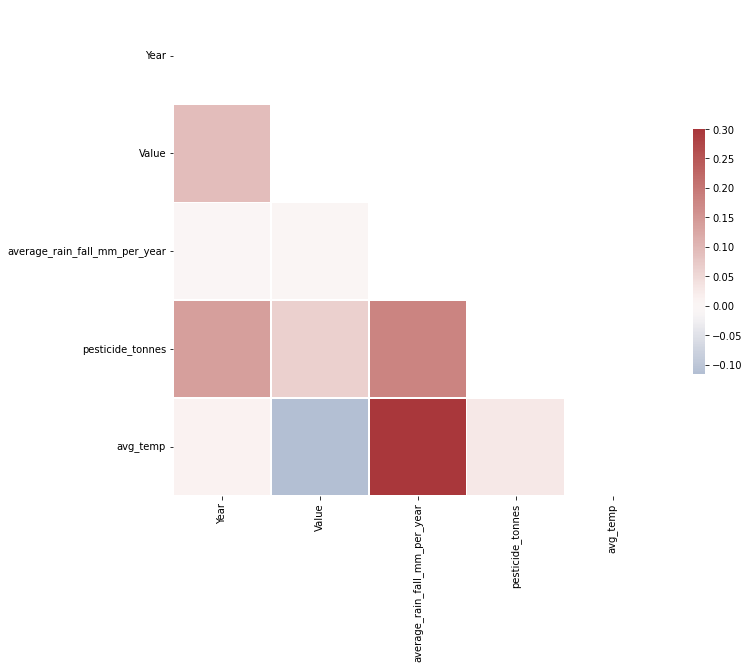

In [52]:
f, ax = plt.subplots(figsize=(11,9))

cmap = sns.palette='vlag'

sns.heatmap(correlation_data, mask=mask, cmap=cmap, vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={'shrink':.5})

The chart above indicates there is no accentuated correlation between any columns in the dataframe. The strongest one, between average rain fall and temperature, amounts to ~0.25

However, it must be stated that a complimentary level of domain knowledge might substantiate a claim of suficient correlation even though the base value seems "low" at ~0.25

In [53]:
# Encoding Categorical Variables (Area and Item)

from sklearn.preprocessing import OneHotEncoder

In [54]:
yield_data.shape

(28242, 7)

In [55]:
yield_data_onehot = pd.get_dummies(yield_data, columns=['Area', 'Item'], prefix=['Country', 'Item'])

yield_data_onehot.head()

,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Botswana,Country_Brazil,Country_Bulgaria,Country_Burkina Faso,Country_Burundi,Country_Cameroon,Country_Canada,Country_Central African Republic,Country_Chile,Country_Colombia,Country_Croatia,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Eritrea,Country_Estonia,Country_Finland,Country_France,Country_Germany,Country_Ghana,...,Country_Niger,Country_Norway,Country_Pakistan,Country_Papua New Guinea,Country_Peru,Country_Poland,Country_Portugal,Country_Qatar,Country_Romania,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sri Lanka,Country_Sudan,Country_Suriname,Country_Sweden,Country_Switzerland,Country_Tajikistan,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Uganda,Country_Ukraine,Country_United Kingdom,Country_Uruguay,Country_Zambia,Country_Zimbabwe,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,36613,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,1990,66667,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1990,23333,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1990,12500,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1990,7000,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [56]:
yield_data_onehot.shape

(28242, 116)

In [57]:
features = yield_data_onehot.loc[:, yield_data_onehot.columns != 'Value']

features.head()

,Year,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Botswana,Country_Brazil,Country_Bulgaria,Country_Burkina Faso,Country_Burundi,Country_Cameroon,Country_Canada,Country_Central African Republic,Country_Chile,Country_Colombia,Country_Croatia,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Eritrea,Country_Estonia,Country_Finland,Country_France,Country_Germany,Country_Ghana,Country_Greece,...,Country_Niger,Country_Norway,Country_Pakistan,Country_Papua New Guinea,Country_Peru,Country_Poland,Country_Portugal,Country_Qatar,Country_Romania,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sri Lanka,Country_Sudan,Country_Suriname,Country_Sweden,Country_Switzerland,Country_Tajikistan,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Uganda,Country_Ukraine,Country_United Kingdom,Country_Uruguay,Country_Zambia,Country_Zimbabwe,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,1990,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1990,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1990,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1990,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [58]:
label = yield_data['Value']

label.head()

0    36613
1    66667
2    23333
3    12500
4     7000
Name: Value, dtype: int64

In [59]:
features = features.drop(['Year'], axis=1)

features.head()

,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Botswana,Country_Brazil,Country_Bulgaria,Country_Burkina Faso,Country_Burundi,Country_Cameroon,Country_Canada,Country_Central African Republic,Country_Chile,Country_Colombia,Country_Croatia,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Eritrea,Country_Estonia,Country_Finland,Country_France,Country_Germany,Country_Ghana,Country_Greece,Country_Guatemala,...,Country_Niger,Country_Norway,Country_Pakistan,Country_Papua New Guinea,Country_Peru,Country_Poland,Country_Portugal,Country_Qatar,Country_Romania,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sri Lanka,Country_Sudan,Country_Suriname,Country_Sweden,Country_Switzerland,Country_Tajikistan,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Uganda,Country_Ukraine,Country_United Kingdom,Country_Uruguay,Country_Zambia,Country_Zimbabwe,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [60]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 28242 entries, 0 to 28241
Columns: 114 entries, average_rain_fall_mm_per_year to Item_Yams
dtypes: float64(3), uint8(111)
memory usage: 3.9 MB


We can verify that some features (columns) have highly different units, magnitude, and ranges (Rainfall and Temperature, for instance)


Left unchanged, this characteristic will make it so some machine learning models attribute higher weights to variables with more substantial magnitudes or ranges. 

Therefore, feature scaling has to be implemented in the dataset.

In [61]:
# Feature Scaling

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features = scaler.fit_transform(features)

In [62]:
features

array([[4.49670743e-01, 3.28894097e-04, 5.13458262e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.49670743e-01, 3.28894097e-04, 5.13458262e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [4.49670743e-01, 3.28894097e-04, 5.13458262e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       ...,
       [1.90028222e-01, 6.93361288e-03, 6.28960818e-01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.90028222e-01, 6.93361288e-03, 6.28960818e-01, ...,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.90028222e-01, 6.93361288e-03, 6.28960818e-01, ...,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00]])

In [63]:
# Train-Test split - Test Size will be 0.3

from sklearn.model_selection import train_test_split

train_data, test_data, train_labels, test_labels = train_test_split(features, label, test_size = 0.3, random_state = 0)

In [64]:
train_data

array([[0.09250549, 0.02988904, 0.56831346, ..., 0.        , 0.        ,
        0.        ],
       [0.32361242, 0.11551133, 0.86405451, ..., 0.        , 0.        ,
        0.        ],
       [0.52712449, 0.01382889, 0.41805792, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.50172468, 0.002385  , 0.88551959, ..., 0.        , 0.        ,
        0.        ],
       [0.32361242, 0.19613182, 0.81839864, ..., 0.        , 0.        ,
        0.        ],
       [0.53621825, 0.15865388, 0.56729131, ..., 0.        , 0.        ,
        1.        ]])

In [65]:
train_labels

20532     65000
12724      7624
21309    482926
10623     10145
17508     88375
          ...  
13123     26016
19648     30762
9845      12500
10799      7825
2732      91353
Name: Value, Length: 19769, dtype: int64

In [66]:
test_data

array([[0.1392286 , 0.07302493, 0.4834753 , ..., 0.        , 1.        ,
        0.        ],
       [0.52085293, 0.00383142, 0.85962521, ..., 0.        , 0.        ,
        0.        ],
       [0.18971464, 0.00560746, 0.20511073, ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.25180307, 0.02753498, 0.52708688, ..., 0.        , 0.        ,
        1.        ],
       [0.18846033, 0.02909897, 0.57410562, ..., 0.        , 0.        ,
        0.        ],
       [0.16933208, 0.17674605, 0.55775128, ..., 0.        , 1.        ,
        0.        ]])

In [67]:
test_labels

25142     33157
25690     92373
18051     33919
4585      31214
18574     16010
          ...  
14441     36070
24746     32037
23734    169492
9374      72195
599       25441
Name: Value, Length: 8473, dtype: int64

In [68]:
# Storing merged yield dataframe to csv

yield_data.to_csv('yield_data.csv')

# Part 3 - Model Comparison and Selection

- Evaluation Metric: R^2 and Adjusted R^2

- Selected Models
  
  1. Gradient Boosting Regressor
  2. Random Forest Regressor
  3. SVM
  4. Decision Tree Regressor

In [69]:
from sklearn.metrics import r2_score

def compare_models(model):

  model_name = model.__class__.__name__
  fit = model.fit(train_data, train_labels)
  y_pred = fit.predict(test_data)
  r2 = r2_score(test_labels, y_pred)
  return([model_name, r2])

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn import svm
from sklearn.tree import DecisionTreeRegressor

models = [
          GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=0),
          RandomForestRegressor(n_estimators=200, max_depth=3, random_state=0),
          svm.SVR(),
          DecisionTreeRegressor()
]

In [71]:
model_train = list(map(compare_models, models))

In [72]:
print(*model_train, sep='\n')

['GradientBoostingRegressor', 0.8914762279966755]
['RandomForestRegressor', 0.6772503033302619]
['SVR', -0.2026434802957715]
['DecisionTreeRegressor', 0.9613347869679971]


We can verify from the results above that **based on R^2 alone**, the Decision Tree Model performs better than all (0.96). The Gradient Boosting Regressor comes in second place (0.89).

However, in a real-life scenario, the risk of **overfitting** needs to be addressed (especially with a 96% R^2 model). 

Moreover, the nature of the data (Stationarity, Heteroskedasticity, Multicollinearity, etc) and **domain knowledge** are crucial factors to determine which model should be used.

Given enough time and resources, there is also the possibility of employing all models above (and many more), attributing weights to each one based on their future predictions accuracy.

In [73]:
yield_data_onehot.head()

,Year,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Botswana,Country_Brazil,Country_Bulgaria,Country_Burkina Faso,Country_Burundi,Country_Cameroon,Country_Canada,Country_Central African Republic,Country_Chile,Country_Colombia,Country_Croatia,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Eritrea,Country_Estonia,Country_Finland,Country_France,Country_Germany,Country_Ghana,...,Country_Niger,Country_Norway,Country_Pakistan,Country_Papua New Guinea,Country_Peru,Country_Poland,Country_Portugal,Country_Qatar,Country_Romania,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sri Lanka,Country_Sudan,Country_Suriname,Country_Sweden,Country_Switzerland,Country_Tajikistan,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Uganda,Country_Ukraine,Country_United Kingdom,Country_Uruguay,Country_Zambia,Country_Zimbabwe,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,1990,36613,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,1990,66667,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,1990,23333,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,1990,12500,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,1990,7000,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [74]:
yield_data_onehot = yield_data_onehot.drop(['Year'], axis=1)

yield_data_onehot.head()

,Value,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Botswana,Country_Brazil,Country_Bulgaria,Country_Burkina Faso,Country_Burundi,Country_Cameroon,Country_Canada,Country_Central African Republic,Country_Chile,Country_Colombia,Country_Croatia,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Eritrea,Country_Estonia,Country_Finland,Country_France,Country_Germany,Country_Ghana,Country_Greece,...,Country_Niger,Country_Norway,Country_Pakistan,Country_Papua New Guinea,Country_Peru,Country_Poland,Country_Portugal,Country_Qatar,Country_Romania,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sri Lanka,Country_Sudan,Country_Suriname,Country_Sweden,Country_Switzerland,Country_Tajikistan,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Uganda,Country_Ukraine,Country_United Kingdom,Country_Uruguay,Country_Zambia,Country_Zimbabwe,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,36613,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,66667,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
2,23333,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
3,12500,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,7000,1485.0,121.0,16.37,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


In [75]:
test_data

array([[0.1392286 , 0.07302493, 0.4834753 , ..., 0.        , 1.        ,
        0.        ],
       [0.52085293, 0.00383142, 0.85962521, ..., 0.        , 0.        ,
        0.        ],
       [0.18971464, 0.00560746, 0.20511073, ..., 0.        , 1.        ,
        0.        ],
       ...,
       [0.25180307, 0.02753498, 0.52708688, ..., 0.        , 0.        ,
        1.        ],
       [0.18846033, 0.02909897, 0.57410562, ..., 0.        , 0.        ,
        0.        ],
       [0.16933208, 0.17674605, 0.55775128, ..., 0.        , 1.        ,
        0.        ]])

In [76]:
test_df = pd.DataFrame(test_data, columns=yield_data_onehot.loc[:, yield_data_onehot.columns != 'Value'].columns)

test_df.head()

,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Botswana,Country_Brazil,Country_Bulgaria,Country_Burkina Faso,Country_Burundi,Country_Cameroon,Country_Canada,Country_Central African Republic,Country_Chile,Country_Colombia,Country_Croatia,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Eritrea,Country_Estonia,Country_Finland,Country_France,Country_Germany,Country_Ghana,Country_Greece,Country_Guatemala,...,Country_Niger,Country_Norway,Country_Pakistan,Country_Papua New Guinea,Country_Peru,Country_Poland,Country_Portugal,Country_Qatar,Country_Romania,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sri Lanka,Country_Sudan,Country_Suriname,Country_Sweden,Country_Switzerland,Country_Tajikistan,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Uganda,Country_Ukraine,Country_United Kingdom,Country_Uruguay,Country_Zambia,Country_Zimbabwe,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,0.139229,0.073025,0.483475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.520853,0.003831,0.859625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.189715,0.005607,0.205111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.536218,0.938137,0.837819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.072437,0.000066,0.888586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [77]:
country = test_df[[col for col in test_df.columns if 'Country' in col]].stack()[test_df[[col for col in test_df.columns if 'Country' in col]].stack()>0]

country

0     Country_South Africa    1.0
1     Country_Sri Lanka       1.0
2     Country_Lithuania       1.0
3     Country_Brazil          1.0
4     Country_Mali            1.0
                             ... 
8468  Country_India           1.0
8469  Country_South Africa    1.0
8470  Country_Portugal        1.0
8471  Country_Greece          1.0
8472  Country_Argentina       1.0
Length: 8473, dtype: float64

In [78]:
country_list = list(pd.DataFrame(country).index.get_level_values(1))

country_list

['Country_South Africa',
 'Country_Sri Lanka',
 'Country_Lithuania',
 'Country_Brazil',
 'Country_Mali',
 'Country_El Salvador',
 'Country_Mali',
 'Country_Ecuador',
 'Country_Pakistan',
 'Country_Indonesia',
 'Country_El Salvador',
 'Country_Ecuador',
 'Country_Italy',
 'Country_Australia',
 'Country_Pakistan',
 'Country_El Salvador',
 'Country_Japan',
 'Country_India',
 'Country_Brazil',
 'Country_Ecuador',
 'Country_Indonesia',
 'Country_Spain',
 'Country_Mexico',
 'Country_Japan',
 'Country_Uganda',
 'Country_Mauritania',
 'Country_Kenya',
 'Country_Germany',
 'Country_Mexico',
 'Country_Saudi Arabia',
 'Country_Algeria',
 'Country_Brazil',
 'Country_Chile',
 'Country_Morocco',
 'Country_Mexico',
 'Country_Libya',
 'Country_Dominican Republic',
 'Country_Angola',
 'Country_Mozambique',
 'Country_Chile',
 'Country_Mexico',
 'Country_Mexico',
 'Country_Mexico',
 'Country_Mali',
 'Country_India',
 'Country_Egypt',
 'Country_Iraq',
 'Country_Mali',
 'Country_United Kingdom',
 'Country_

In [79]:
countries = [i.split("_")[1] for i in country_list]

countries

['South Africa',
 'Sri Lanka',
 'Lithuania',
 'Brazil',
 'Mali',
 'El Salvador',
 'Mali',
 'Ecuador',
 'Pakistan',
 'Indonesia',
 'El Salvador',
 'Ecuador',
 'Italy',
 'Australia',
 'Pakistan',
 'El Salvador',
 'Japan',
 'India',
 'Brazil',
 'Ecuador',
 'Indonesia',
 'Spain',
 'Mexico',
 'Japan',
 'Uganda',
 'Mauritania',
 'Kenya',
 'Germany',
 'Mexico',
 'Saudi Arabia',
 'Algeria',
 'Brazil',
 'Chile',
 'Morocco',
 'Mexico',
 'Libya',
 'Dominican Republic',
 'Angola',
 'Mozambique',
 'Chile',
 'Mexico',
 'Mexico',
 'Mexico',
 'Mali',
 'India',
 'Egypt',
 'Iraq',
 'Mali',
 'United Kingdom',
 'Mexico',
 'Bangladesh',
 'Angola',
 'Peru',
 'Brazil',
 'Poland',
 'Japan',
 'Pakistan',
 'Namibia',
 'India',
 'Bangladesh',
 'Cameroon',
 'Saudi Arabia',
 'Brazil',
 'India',
 'Pakistan',
 'Argentina',
 'Ecuador',
 'Japan',
 'Turkey',
 'Pakistan',
 'Mali',
 'South Africa',
 'Burkina Faso',
 'Mauritania',
 'Madagascar',
 'Iraq',
 'Japan',
 'Poland',
 'Bulgaria',
 'South Africa',
 'India',
 'Mozam

In [80]:
item = test_df[[col for col in test_df.columns if 'Item' in col]].stack()[test_df[[col for col in test_df.columns if 'Item' in col]].stack()>0]

item

0     Item_Wheat             1.0
1     Item_Cassava           1.0
2     Item_Wheat             1.0
3     Item_Soybeans          1.0
4     Item_Soybeans          1.0
                            ... 
8468  Item_Rice, paddy       1.0
8469  Item_Sweet potatoes    1.0
8470  Item_Yams              1.0
8471  Item_Rice, paddy       1.0
8472  Item_Wheat             1.0
Length: 8473, dtype: float64

In [81]:
item_list = list(pd.DataFrame(item).index.get_level_values(1))

item_list

['Item_Wheat',
 'Item_Cassava',
 'Item_Wheat',
 'Item_Soybeans',
 'Item_Soybeans',
 'Item_Cassava',
 'Item_Maize',
 'Item_Sweet potatoes',
 'Item_Potatoes',
 'Item_Sweet potatoes',
 'Item_Potatoes',
 'Item_Soybeans',
 'Item_Soybeans',
 'Item_Potatoes',
 'Item_Soybeans',
 'Item_Sweet potatoes',
 'Item_Yams',
 'Item_Sweet potatoes',
 'Item_Sorghum',
 'Item_Cassava',
 'Item_Rice, paddy',
 'Item_Soybeans',
 'Item_Potatoes',
 'Item_Wheat',
 'Item_Wheat',
 'Item_Potatoes',
 'Item_Sorghum',
 'Item_Soybeans',
 'Item_Potatoes',
 'Item_Potatoes',
 'Item_Maize',
 'Item_Wheat',
 'Item_Wheat',
 'Item_Soybeans',
 'Item_Sweet potatoes',
 'Item_Wheat',
 'Item_Cassava',
 'Item_Wheat',
 'Item_Potatoes',
 'Item_Potatoes',
 'Item_Potatoes',
 'Item_Maize',
 'Item_Sorghum',
 'Item_Wheat',
 'Item_Rice, paddy',
 'Item_Sweet potatoes',
 'Item_Soybeans',
 'Item_Wheat',
 'Item_Potatoes',
 'Item_Potatoes',
 'Item_Maize',
 'Item_Soybeans',
 'Item_Wheat',
 'Item_Soybeans',
 'Item_Wheat',
 'Item_Maize',
 'Item_Sorgh

In [82]:
items = [i.split("_")[1] for i in item_list]

items

['Wheat',
 'Cassava',
 'Wheat',
 'Soybeans',
 'Soybeans',
 'Cassava',
 'Maize',
 'Sweet potatoes',
 'Potatoes',
 'Sweet potatoes',
 'Potatoes',
 'Soybeans',
 'Soybeans',
 'Potatoes',
 'Soybeans',
 'Sweet potatoes',
 'Yams',
 'Sweet potatoes',
 'Sorghum',
 'Cassava',
 'Rice, paddy',
 'Soybeans',
 'Potatoes',
 'Wheat',
 'Wheat',
 'Potatoes',
 'Sorghum',
 'Soybeans',
 'Potatoes',
 'Potatoes',
 'Maize',
 'Wheat',
 'Wheat',
 'Soybeans',
 'Sweet potatoes',
 'Wheat',
 'Cassava',
 'Wheat',
 'Potatoes',
 'Potatoes',
 'Potatoes',
 'Maize',
 'Sorghum',
 'Wheat',
 'Rice, paddy',
 'Sweet potatoes',
 'Soybeans',
 'Wheat',
 'Potatoes',
 'Potatoes',
 'Maize',
 'Soybeans',
 'Wheat',
 'Soybeans',
 'Wheat',
 'Maize',
 'Sorghum',
 'Maize',
 'Rice, paddy',
 'Rice, paddy',
 'Sorghum',
 'Sorghum',
 'Wheat',
 'Wheat',
 'Rice, paddy',
 'Rice, paddy',
 'Cassava',
 'Wheat',
 'Maize',
 'Potatoes',
 'Wheat',
 'Sweet potatoes',
 'Yams',
 'Potatoes',
 'Cassava',
 'Maize',
 'Sweet potatoes',
 'Wheat',
 'Potatoes',
 '

In [83]:
test_df.head()

,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country_Albania,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,Country_Azerbaijan,Country_Bahamas,Country_Bahrain,Country_Bangladesh,Country_Belarus,Country_Belgium,Country_Botswana,Country_Brazil,Country_Bulgaria,Country_Burkina Faso,Country_Burundi,Country_Cameroon,Country_Canada,Country_Central African Republic,Country_Chile,Country_Colombia,Country_Croatia,Country_Denmark,Country_Dominican Republic,Country_Ecuador,Country_Egypt,Country_El Salvador,Country_Eritrea,Country_Estonia,Country_Finland,Country_France,Country_Germany,Country_Ghana,Country_Greece,Country_Guatemala,...,Country_Niger,Country_Norway,Country_Pakistan,Country_Papua New Guinea,Country_Peru,Country_Poland,Country_Portugal,Country_Qatar,Country_Romania,Country_Rwanda,Country_Saudi Arabia,Country_Senegal,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sri Lanka,Country_Sudan,Country_Suriname,Country_Sweden,Country_Switzerland,Country_Tajikistan,Country_Thailand,Country_Tunisia,Country_Turkey,Country_Uganda,Country_Ukraine,Country_United Kingdom,Country_Uruguay,Country_Zambia,Country_Zimbabwe,Item_Cassava,Item_Maize,Item_Plantains and others,Item_Potatoes,"Item_Rice, paddy",Item_Sorghum,Item_Soybeans,Item_Sweet potatoes,Item_Wheat,Item_Yams
0,0.139229,0.073025,0.483475,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.520853,0.003831,0.859625,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.189715,0.005607,0.205111,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.536218,0.938137,0.837819,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.072437,0.000066,0.888586,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [84]:
test_df.drop([col for col in test_df.columns if 'Item' in col], axis=1, inplace=True)

test_df.drop([col for col in test_df.columns if 'Country' in col], axis=1, inplace=True)

test_df.head()

,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp
0,0.139229,0.073025,0.483475
1,0.520853,0.003831,0.859625
2,0.189715,0.005607,0.205111
3,0.536218,0.938137,0.837819
4,0.072437,0.000066,0.888586


In [85]:
test_df['Country'] = countries

test_df['Item'] = items

test_df.head()

,average_rain_fall_mm_per_year,pesticide_tonnes,avg_temp,Country,Item
0,0.139229,0.073025,0.483475,South Africa,Wheat
1,0.520853,0.003831,0.859625,Sri Lanka,Cassava
2,0.189715,0.005607,0.205111,Lithuania,Wheat
3,0.536218,0.938137,0.837819,Brazil,Soybeans
4,0.072437,0.000066,0.888586,Mali,Soybeans


In [97]:
clf = DecisionTreeRegressor()
model = clf.fit(train_data, train_labels)

test_df['yield_predicted'] = model.predict(test_data)
test_df['yield_actual'] = pd.DataFrame(test_labels)['Value'].tolist()
test_group = test_df.groupby('Item')
test_group.apply(lambda x: r2_score(x.yield_actual, x.yield_predicted))

Item
Cassava                 0.919819
Maize                   0.875894
Plantains and others    0.780193
Potatoes                0.905182
Rice, paddy             0.885051
Sorghum                 0.835109
Soybeans                0.842079
Sweet potatoes          0.918159
Wheat                   0.933987
Yams                    0.873086
dtype: float64

As verified above, the Decision Tree Model has performs well with all kinds of crops, although there is a 15 points difference between "Plaintain and others" (78%) and Wheat (93%) 

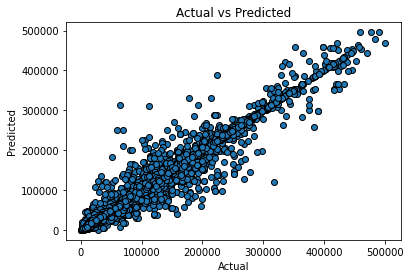

In [87]:
# Visualizing results

fig, ax = plt.subplots()

ax.scatter(test_df['yield_actual'], test_df['yield_predicted'], edgecolors=(0,0,0))

ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted')
plt.show()

In [88]:
def adjusted_r_squared(y, yhat, x):

  score = 1 - (((1 - (r2_score(y, yhat))) * len((y)-1)) / (len(y) - x.shape[1]-2))

  return score

In [89]:
test_group.apply(lambda x: adjusted_r_squared(x.yield_actual, x.yield_predicted, x))

Item
Cassava                 0.916768
Maize                   0.881111
Plantains and others    0.765817
Potatoes                0.906947
Rice, paddy             0.885732
Sorghum                 0.853857
Soybeans                0.834087
Sweet potatoes          0.920057
Wheat                   0.931485
Yams                    0.877521
dtype: float64

Once again, "Wheat" presents the best Adjusted R^2 whereas "Plaintains and others", the worst. This might be indicative of missing factors to better explain plaintain crop yields.

# Part 4 - Results and Conclusions

In [90]:
varimp = {'imp':model.feature_importances_, 'names':yield_data_onehot.columns[yield_data_onehot.columns != 'Value']}

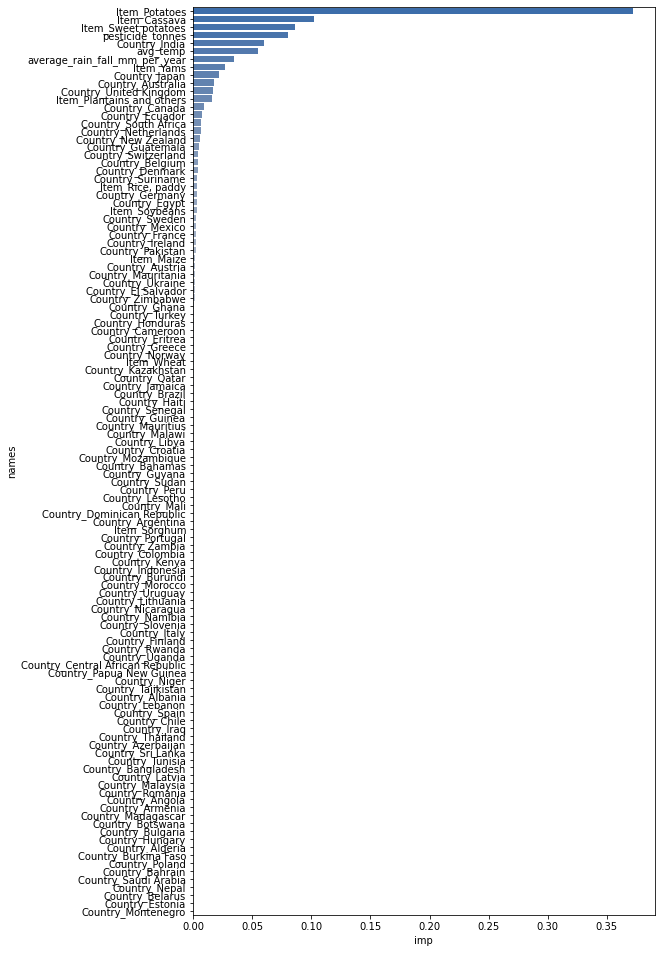

In [91]:
a4_dims = (8.27, 16.7)

fig, ax = plt.subplots(figsize=a4_dims)
df = pd.DataFrame.from_dict(varimp)
df.sort_values(ascending=False, by=['imp'], inplace=True)
df = df.dropna()
sns.barplot(x='imp', y='names', palette='vlag', data=df, orient='h', ax=ax)

Barplot indicates feature importance restricted to ~first 7 variables

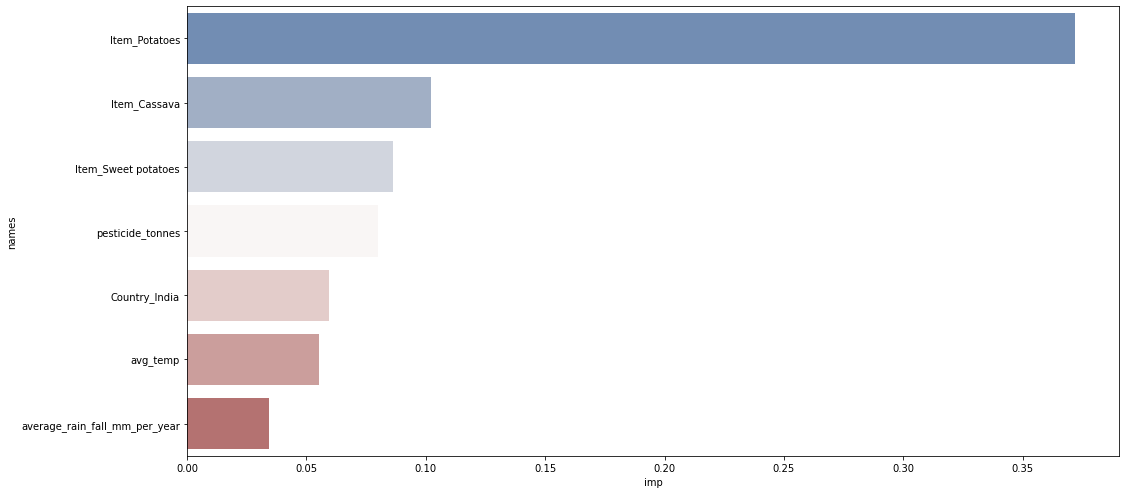

In [92]:
a4_dims = (16.7, 8.27)

fig, ax = plt.subplots(figsize=a4_dims)
df = pd.DataFrame.from_dict(varimp)
df.sort_values(ascending=False, by=['imp'], inplace=True)
df = df.dropna()
df = df.nlargest(7, 'imp')
sns.barplot(x='imp', y='names', palette='vlag', data=df, orient='h', ax=ax)

Regarding the 7 most influential variables, potatoes (the crop being a potato) seems to be the most important by a substantial margin. 


As we recall from the preliminary analysis, potatoes are the most popular crop in this dataset, and this high frequency might be translated into more training opportunities (or examples) for this crop. In other words, there are more instances of potatoes in the dataset, making the model more "confident" in forecasting a particular yield given that it had more opportunities to correlate yields with this variable, compared to others.


The same logic applies to Cassavas, Sweet Potatoes, and Country India. All are appear with high frequency on this dataset. 

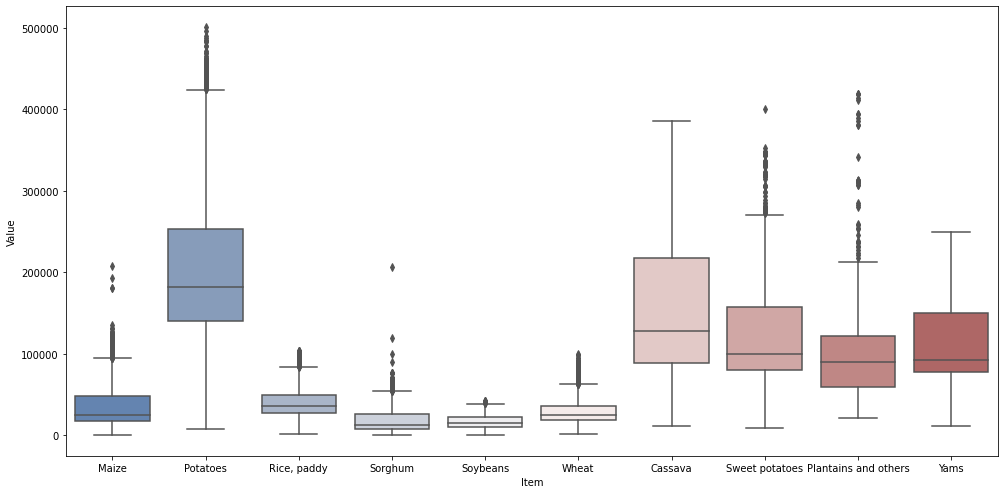

In [93]:
a4_dims = (16.7, 8.27)

fig, ax = plt.subplots(figsize=a4_dims)
sns.boxplot(x='Item', y='Value', palette='vlag', data=yield_data, ax=ax)

In [94]:
import pickle
filename = 'yield_forecast_model.sav'

# Potential Next Steps

1. Evaluate Models against newer datasets to investigate performance and risk of overfitting
2. Perform Grid Search on selected models to optimize chosen parameters
3. Assign weights to different models based on performance
3. Deploy models as interactive web application, using platforms such as Streamlit